In [ ]:
# Given a saved dataframe with all seeds and their corresponding policies, recover the latents

In [36]:
from diffusers import AutoPipelineForText2Image

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
torch.cuda.empty_cache()
pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "stabilityai/sdxl-turbo",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerAncestralDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [143]:
def get_latent_list_from_seeds(seeds: list[int]) -> list[Latent]:
    generators = [torch.Generator(device="cpu").manual_seed(seed) for seed in seeds]
    latents = [
            pipe.prepare_latents(
                batch_size=1,
                num_channels_latents=pipe.unet.config.in_channels,
                height=512,
                width=512,
                dtype=pipe.unet.dtype,
                device="cpu",
                generator=generator,
            )[0] / pipe.scheduler.init_noise_sigma
            for generator in generators
        ]
    return latents

In [32]:
# As an example, load in latent_alpha=0.25_10x10
import pandas as pd
example_df = pd.read_csv("results/latent_alpha=0.25_10x10/metrics.csv")
example_df["alpha"] = 0.25

In [144]:
# Each datapoint for a round is one favorite image, and three/two non-favorite images
from typing import NamedTuple
import torch

Latent = torch.Tensor # we'll represent as 3-dimensional, not 4-dimensional. We'll add the first dimension (batch size) only when needed.

class DataPoint(NamedTuple):
    round: int
    trial_id: str
    prompt_id: str
    alpha: float
    favorite_latent: Latent
    non_favorite_latents: list[Latent]

In [145]:
def get_data_point(df: pd.DataFrame, round: int, trial_id: str, prompt_id: str, alpha: float) -> tuple[DataPoint, DataPoint]:
    """
    Given a dataframe with all seeds and their corresponding policies,
    round: must be 0-4
    trial_id: str in "trial0" to "trial9"
    prompt_id: str
    alpha: float
    """
    # first, gather the four rows corresponding to this round, trial, and prompt
    rows = df[(df["round"] == round) & (df["trial_id"] == trial_id) & (df["prompt_id"] == prompt_id) & (df["alpha"] == alpha)]

    # If not 4 rows, raise an error
    if len(rows) != 4:
        raise ValueError(f"Expected 4 rows for round {round}, trial {trial_id}, prompt {prompt_id}, got {len(rows)}")
    
    # if on the first round, just use the latents
    if round == 0:
        # get the single favorite latent, by selecting chosen, getting the seed
        favorite_latent_seed: int = rows[rows["chosen"] == True]["seed"].item()
        print("favorite_latent_seed", favorite_latent_seed)
        favorite_latent: Latent = get_latent_list_from_seeds([favorite_latent_seed])[0]

        # get the three non-favorite latents, by selecting not chosen
        non_favorite_latents_seeds: list[int] = rows[rows["chosen"] == False]["seed"].tolist()
        print("non_favorite_latents_seeds", non_favorite_latents_seeds)
        non_favorite_latents: list[Latent] = get_latent_list_from_seeds(non_favorite_latents_seeds)
    
    return DataPoint(round, trial_id, prompt_id, alpha, favorite_latent, non_favorite_latents)

In [104]:
example_df

,prompt_id,trial_id,round,image_idx,image_path,user_score,chosen,prompt,seed,mean_pixel,reused_from_previous,alpha
0,001369-0084,trial0,0,0,outputs/2025-12-03_04-14-38/images/001369-0084...,-0.837507,False,greek or roman sculpture in marble of a philos...,83811,0.413702,False,0.25
1,001369-0084,trial0,0,1,outputs/2025-12-03_04-14-38/images/001369-0084...,1.323117,False,greek or roman sculpture in marble of a philos...,14593,0.432384,False,0.25
2,001369-0084,trial0,0,2,outputs/2025-12-03_04-14-38/images/001369-0084...,1.191764,False,greek or roman sculpture in marble of a philos...,3279,0.406613,False,0.25
3,001369-0084,trial0,0,3,outputs/2025-12-03_04-14-38/images/001369-0084...,1.466751,True,greek or roman sculpture in marble of a philos...,97197,0.408617,False,0.25
4,001369-0084,trial0,1,0,outputs/2025-12-03_04-14-38/images/001369-0084...,1.466751,False,greek or roman sculpture in marble of a philos...,97197,0.408617,True,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...
1595,005695-0057,trial9,2,3,outputs/2025-12-03_04-14-38/images/005695-0057...,1.157937,False,"a concept art of a vehicle, cyberpunk",69943,0.343295,False,0.25
1596,005695-0057,trial9,3,0,outputs/2025-12-03_04-14-38/images/005695-0057...,1.311723,False,"a concept art of a vehicle, cyberpunk",88390,0.339938,True,0.25
1597,005695-0057,trial9,3,1,outputs/2025-12-03_04-14-38/images/005695-0057...,1.009201,False,"a concept art of a vehicle, cyberpunk",49809,0.358998,False,0.25
1598,005695-0057,trial9,3,2,outputs/2025-12-03_04-14-38/images/005695-0057...,1.037068,False,"a concept art of a vehicle, cyberpunk",41506,0.356494,False,0.25


In [146]:
example_round = 0
example_trial_id = "trial9"
example_prompt_id="005695-0057"
example_alpha = 0.25

example_data_point = get_data_point(example_df, round=example_round, trial_id=example_trial_id, prompt_id=example_prompt_id, alpha=example_alpha)

# Get the prompt from the prompt id
example_prompt: str = example_df[example_df["prompt_id"] == example_prompt_id]["prompt"].unique().item()

favorite_latent_seed 34738
non_favorite_latents_seeds [44376, 81692, 90795]


In [147]:
example_data_point.favorite_latent.shape

torch.Size([4, 64, 64])

  0%|          | 0/1 [00:00<?, ?it/s]

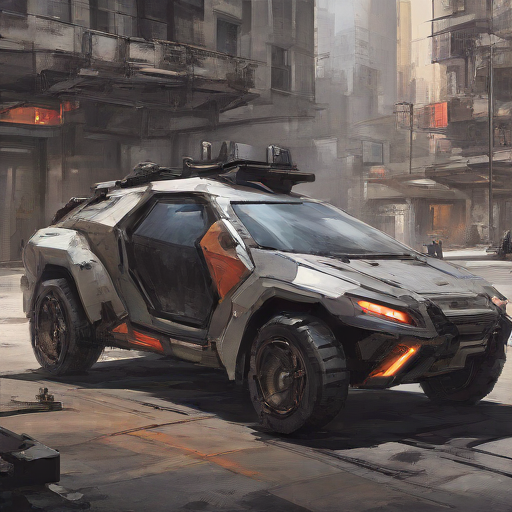

In [153]:
favorite_image = pipe(
    prompt=example_prompt,
    num_images_per_prompt=1,
    latents=example_data_point.non_favorite_latents[0].unsqueeze(0),
    width=512,
    height=512,
    num_inference_steps=1,
    guidance_scale=0.0,
).images[0]

# display
display(favorite_image)


In [151]:
# display the actual based on the example
example_rows = example_df[(example_df["round"] == example_round) & (example_df["trial_id"] == example_trial_id) & (example_df["prompt_id"] == example_prompt_id) & (example_df["alpha"] == example_alpha)]
favorite_row = example_rows[example_rows["chosen"] == True]
non_favorite_rows = example_rows[example_rows["chosen"] == False]

In [152]:
non_favorite_rows

,prompt_id,trial_id,round,image_idx,image_path,user_score,chosen,prompt,seed,mean_pixel,reused_from_previous,alpha
1585,005695-0057,trial9,0,1,outputs/2025-12-03_04-14-38/images/005695-0057...,0.900294,False,"a concept art of a vehicle, cyberpunk",44376,0.353177,False,0.25
1586,005695-0057,trial9,0,2,outputs/2025-12-03_04-14-38/images/005695-0057...,1.061767,False,"a concept art of a vehicle, cyberpunk",81692,0.358715,False,0.25
1587,005695-0057,trial9,0,3,outputs/2025-12-03_04-14-38/images/005695-0057...,1.035664,False,"a concept art of a vehicle, cyberpunk",90795,0.345814,False,0.25


In [140]:
import PIL
from pathlib import Path
start_path = Path(f"results/latent_alpha={example_alpha}_10x10")

old_actual_favorite_image_path: Path = Path(favorite_row["image_path"].item())
# replace the first two parts of the path with start path
actual_favorite_image_path: Path = start_path / Path(*old_actual_favorite_image_path.parts[2:])

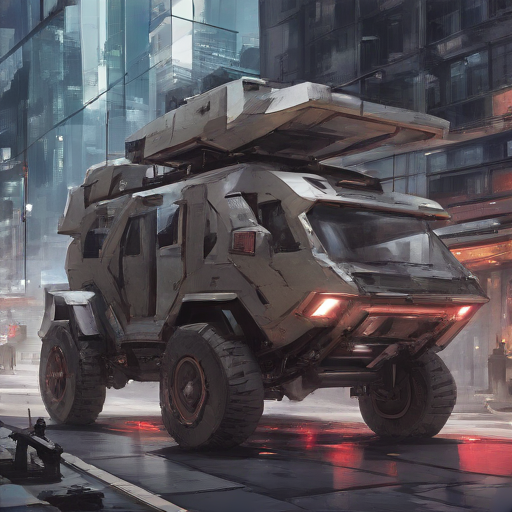

In [ ]:
# Load the image
actual_favorite_image = PIL.Image.open(actual_favorite_image_path)
display(actual_favorite_image)